In [5]:
from hmm import HiddenMarkovModel
import numpy as np
import matplotlib.pyplot as plt
if __name__ == "__main__":
    states  = ['E', '5', 'I']
    symbols = ['A', 'C', 'G', 'T']

    pi = np.array([1.0, 0.0, 0.0])

    #         E     5     I
    A = np.array([
        [0.9, 0.1, 0.0],   # из E
        [0.0, 0.0, 1.0],   # из 5
        [0.0, 0.0, 0.9],   # из I (0.1 уходит в END)
    ])

    #         A     C     G     T
    B = np.array([
        [0.25, 0.25, 0.25, 0.25],   # E
        [0.05, 0.00, 0.95, 0.00],   # 5
        [0.40, 0.10, 0.10, 0.40],   # I
    ])

    # только из I можно завершить последовательность
    end_prob = np.array([0.0, 0.0, 0.1])

    seq = list('CTTCATGTGAAAGCAGACGTAAGTCA')

    hmm = HiddenMarkovModel(states, symbols, pi, A, B, end_prob=end_prob)

    # Viterbi
    v = hmm.viterbi(seq)
    print("=== Viterbi ===")
    print("Sequence:        ", " ".join(seq))
    print("Most likely path:", " ".join(v.path))
    print(f"log P = {v.log_prob:.4f}")

    # Forward
    f = hmm.forward(seq)
    print(f"\n=== Forward ===\nlog P(O | λ) = {f.log_prob:.4f}")

    # Backward
    b = hmm.backward(seq)
    print(f"\n=== Backward ===\nlog P(O | λ) = {b.log_prob:.4f}  (должно совпадать с Forward)")

    # Posterior
    p = hmm.posterior_decoding(seq)
    print(f"\n=== Posterior decoding ===\nlog P(O | λ) = {p.log_prob:.4f}")
    header = f"{'t':>3}  {'obs':>4}" + "".join(f"  {s:>8}" for s in states) + f"  {'best':>5}"
    print(header)
    for t, (nuc, row, state) in enumerate(zip(seq, p.gamma, p.states_at_each_step)):
        cols = "".join(f"  {row[i]:>8.4f}" for i in range(len(states)))
        print(f"{t:>3}  {nuc:>4}{cols}  {state:>5}")



=== Viterbi ===
Sequence:         C T T C A T G T G A A A G C A G A C G T A A G T C A
Most likely path: E E E E E E E E E E E E E E E E E E 5 I I I I I I I
log P = -41.2197

=== Forward ===
log P(O | λ) = -40.4474

=== Backward ===
log P(O | λ) = -40.4474  (должно совпадать с Forward)

=== Posterior decoding ===
log P(O | λ) = -40.4474
  t   obs         E         5         I   best
  0     C    1.0000    0.0000    0.0000      E
  1     T    1.0000    0.0000    0.0000      E
  2     T    1.0000    0.0000    0.0000      E
  3     C    1.0000    0.0000    0.0000      E
  4     A    0.9989    0.0011    0.0000      E
  5     T    0.9989    0.0000    0.0011      E
  6     G    0.9672    0.0317    0.0011      E
  7     T    0.9672    0.0000    0.0328      E
  8     G    0.9176    0.0496    0.0328      E
  9     A    0.9159    0.0016    0.0824      E
 10     A    0.9149    0.0010    0.0841      E
 11     A    0.9143    0.0006    0.0851      E
 12     G    0.8840    0.0303    0.0857      E
 13 

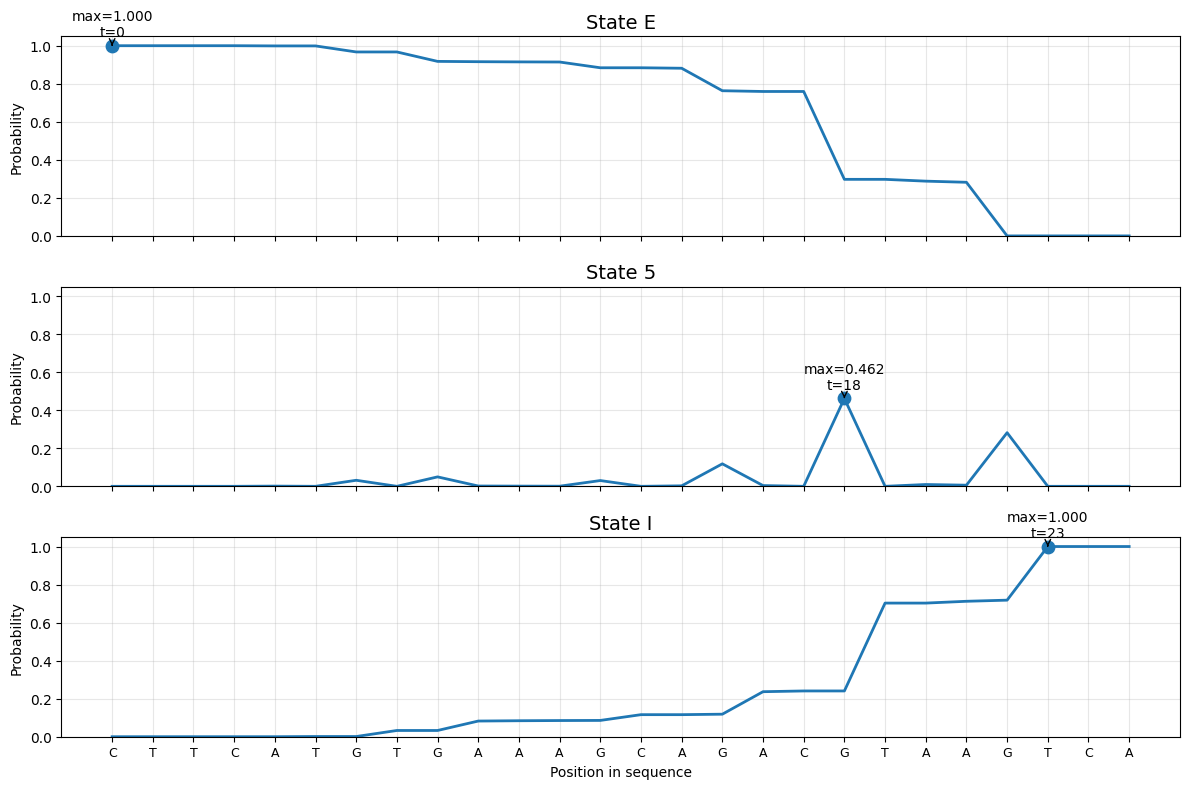

In [6]:
gamma = np.array(p.gamma)   # shape: (T, N)
T = gamma.shape[0]
x = np.arange(T)

state_names = states  # ['E', '5', 'I']

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, ax in enumerate(axes):
    probs = gamma[:, i]

    # Plot line
    ax.plot(x, probs, linewidth=2)

    # Find maximum
    max_idx = np.argmax(probs)
    max_val = probs[max_idx]

    # Mark maximum
    ax.scatter(max_idx, max_val, s=80, zorder=3)
    ax.annotate(f"max={max_val:.3f}\nt={max_idx}",
                xy=(max_idx, max_val),
                xytext=(max_idx, max_val + 0.05),
                ha='center',
                fontsize=10,
                arrowprops=dict(arrowstyle="->", lw=1))

    # Titles & styling
    ax.set_title(f"State {state_names[i]}", fontsize=14)
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

# X-axis formatting
axes[-1].set_xlabel("Position in sequence")
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(seq, fontsize=9)

plt.tight_layout()
plt.show()